# Modèle 1 — Prévision des Ventes

## Objectif

Ce notebook implémente un modèle de prévision du chiffre d'affaires hebdomadaire à partir du dataset Olist.  
L'objectif est de prédire les ventes futures afin d'aider à la **gestion des stocks** et à la **planification stratégique**.

## Pipeline

```
1. Chargement des 4 tables
2. Traitement des valeurs manquantes & doublons (colonnes utilisées uniquement)
3. Fusion & construction du dataset modèle
4. Agrégation hebdomadaire par catégorie
5. Feature Engineering (lag, rolling, temporel)
6. Split chronologique Train / Test
7. Entraînement & comparaison — Linear Regression / Random Forest / XGBoost
8. Interprétabilité — SHAP Values
9. Visualisation des prédictions
10. Synthèse
```

## Tables utilisées

| Table | Colonnes utilisées | Rôle |
|---|---|---|
| `olist_orders_dataset.csv` | order_id, order_purchase_timestamp, order_status | Dimension temporelle |
| `olist_order_items_dataset.csv` | order_id, price, freight_value | Variable cible Y (CA) |
| `olist_products_dataset.csv` | product_id, product_category_name | Dimension catégorie |
| `product_category_name_translation.csv` | les deux colonnes | Traduction catégories |

## 🎯 Contexte Métier — Pourquoi prévoir les ventes ?

**Olist** est une marketplace e-commerce brésilienne.  
Ce modèle prédit le **CA hebdomadaire par catégorie de produit** (prévision semaine suivante).

| Profil | Décision |
|--------|----------|
| 🏭 **Opérations** | Préparer les stocks 7 jours à l'avance |
| 📦 **Logistique** | Anticiper le volume de commandes à traiter |
| 📊 **Direction** | Suivre la tendance et planifier le budget |

> **Granularité choisie : hebdomadaire** — adaptée aux 25 mois de données disponibles (R² = 0.98).
### Exemple concret de décision

> *La semaine du **2018-07-02**, le modèle prédit que la catégorie*  
> *`health_beauty` va générer **~18,000 BRL** de CA.*  
> *→ Le responsable logistique commande les stocks nécessaires dès maintenant.*  
> *→ Le service client prépare une équipe dimensionnée pour le volume attendu.*


In [17]:
!pip install "numpy<2"

  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1 — Imports

In [18]:
# ─────────────────────────────────────────────
# CELLULE 1 — Imports
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Style global (cohérent avec ETL notebook)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"]   = "#f8f8f8"
plt.rcParams["font.family"]      = "DejaVu Sans"
sns.set_palette("husl")

print("Imports OK")

Imports OK


## 2 — Chargement des données

In [19]:
# ─────────────────────────────────────────────
# CELLULE 2 — Chargement des 4 fichiers CSV
# ─────────────────────────────────────────────

DATA_PATH = "./DataM/"   # ← adapter si nécessaire

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv",
                     parse_dates=["order_purchase_timestamp"])

items  = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")

prods  = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")

transl = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

for name, df in {"orders": orders, "items": items,
                 "products": prods, "translation": transl}.items():
    print(f"   {name:<12} → {df.shape[0]:>7,} lignes   {df.shape[1]:>2} colonnes")

   orders       →  99,441 lignes    8 colonnes
   items        → 112,650 lignes    7 colonnes
   products     →  32,951 lignes    9 colonnes
   translation  →      71 lignes    2 colonnes


## 3 — Traitement des données

L'audit complet a été réalisé dans le notebook ETL (Phase 2).  
Ici on applique uniquement les traitements **nécessaires aux colonnes utilisées** par ce modèle :

| Table | Problème identifié | Traitement |
|---|---|---|
| `orders` | 0 doublon, 0 valeur manquante sur les colonnes utilisées | Aucun traitement nécessaire |
| `items` | 0 doublon, 0 valeur manquante | Aucun traitement nécessaire |
| `products` | 610 valeurs manquantes sur `product_category_name` (1.85%) | Missing flag + imputation `"unknown"` → exclusion en modélisation |
| `translation` | 0 doublon, 0 valeur manquante | Aucun traitement nécessaire |

In [20]:
# ─────────────────────────────────────────────
# CELLULE 3 — Traitement products
# (seul dataset avec valeurs manquantes sur
#  les colonnes utilisées par ce modèle)
# ─────────────────────────────────────────────

products_clean = prods[["product_id", "product_category_name"]].copy()

# Missing flag (traçabilité — cohérent avec stratégie ETL)
products_clean["missing_category"] = products_clean["product_category_name"].isnull().astype(int)

# Imputation catégorielle → "unknown"
products_clean["product_category_name"] = (
    products_clean["product_category_name"].fillna("unknown")
)

print(f"Produits avec missing_category=1 : {products_clean['missing_category'].sum():,}")
print(f"Catégorie imputée 'unknown'       : {(products_clean['product_category_name'] == 'unknown').sum():,}")
print(f"Doublons sur product_id           : {products_clean['product_id'].duplicated().sum():,}")
print()
print("→ Les lignes 'unknown' seront exclues à l'étape de construction du dataset modèle.")

Produits avec missing_category=1 : 610
Catégorie imputée 'unknown'       : 610
Doublons sur product_id           : 0

→ Les lignes 'unknown' seront exclues à l'étape de construction du dataset modèle.


## 4 — Construction du dataset modèle

### 4.1 — Filtrage : commandes livrées uniquement

Seules les commandes `order_status == 'delivered'` sont conservées.  
Les statuts annulés, en transit, etc. introduiraient du bruit dans la variable cible.

In [22]:
# ─────────────────────────────────────────────
# CELLULE 4 — Filtrage commandes livrées
# ─────────────────────────────────────────────

orders_clean = orders[
    orders["order_status"] == "delivered"
][["order_id", "order_purchase_timestamp"]].copy()

print(f"Commandes totales  : {len(orders):,}")
print(f"Commandes livrées  : {len(orders_clean):,}  ({len(orders_clean)/len(orders)*100:.1f}%)")
print(f"Commandes exclues  : {len(orders) - len(orders_clean):,}")

Commandes totales  : 99,441
Commandes livrées  : 96,478  (97.0%)
Commandes exclues  : 2,963


### 4.2 — Fusion des 4 tables

```
orders_clean  ──INNER──▶  items           (order_id)
                    └───LEFT───▶  products_clean  (product_id)
                                      └───LEFT───▶  transl  (product_category_name)
```

- **INNER** sur items : ne conserver que les commandes avec au moins 1 article
- **LEFT** sur products : conserver toutes les lignes, même si le produit est inconnu
- **LEFT** sur translation : ajouter la version anglaise de la catégorie

In [23]:
# ─────────────────────────────────────────────
# CELLULE 5 — Fusion des 4 tables
# ─────────────────────────────────────────────

# orders × items
df = pd.merge(
    orders_clean,
    items[["order_id", "product_id", "price", "freight_value"]],
    on="order_id", how="inner"
)
print(f"orders × items       : {df.shape}")

# × products
df = pd.merge(
    df,
    products_clean[["product_id", "product_category_name", "missing_category"]],
    on="product_id", how="left"
)
print(f"× products           : {df.shape}")

# × translation
df = pd.merge(df, transl, on="product_category_name", how="left")
print(f"× translation        : {df.shape}")

# Variable cible
df["revenue"] = df["price"] + df["freight_value"]

print(f"\nDataset fusionné : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

orders × items       : (110197, 5)
× products           : (110197, 7)
× translation        : (110197, 8)

Dataset fusionné : 110,197 lignes × 9 colonnes


### 4.3 — Exclusion des catégories 'unknown'

Conformément à la stratégie ETL du projet : les valeurs imputées `"unknown"` sont exclues  
de la phase de modélisation afin d'éviter tout biais dans les prédictions par catégorie.

In [24]:
# ─────────────────────────────────────────────
# CELLULE 6 — Exclusion des 'unknown'
# ─────────────────────────────────────────────

# Fallback : si pas de traduction, garder le nom portugais
df["product_category_name_english"] = (
    df["product_category_name_english"]
    .fillna(df["product_category_name"])
)

before   = len(df)
df_model = df[df["product_category_name_english"] != "unknown"].copy()
after    = len(df_model)

print(f"Lignes avant exclusion   : {before:,}")
print(f"Lignes après exclusion   : {after:,}")
print(f"Lignes exclues (unknown) : {before - after:,}  ({(before-after)/before*100:.2f}%)")
print(f"Catégories distinctes    : {df_model['product_category_name_english'].nunique()}")

Lignes avant exclusion   : 110,197
Lignes après exclusion   : 108,660
Lignes exclues (unknown) : 1,537  (1.39%)
Catégories distinctes    : 73


## 5 — Agrégation hebdomadaire par catégorie

La variable cible du modèle est le **CA hebdomadaire par catégorie de produit**.  
Chaque ligne = 1 semaine × 1 catégorie.

In [25]:
# ─────────────────────────────────────────────
# CELLULE 7 — Agrégation hebdomadaire
# ─────────────────────────────────────────────

df_model["week_start"] = (
    df_model["order_purchase_timestamp"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

weekly = (
    df_model
    .groupby(["week_start", "product_category_name_english"])
    .agg(
        CA        = ("revenue",  "sum"),
        nb_orders = ("order_id", "nunique"),
        avg_price = ("price",    "mean")
    )
    .reset_index()
    .sort_values("week_start")
    .reset_index(drop=True)
)

print(f"Dataset hebdomadaire : {weekly.shape}")
print(f"Période couverte     : {weekly['week_start'].min().date()} → {weekly['week_start'].max().date()}")
print(f"Semaines distinctes  : {weekly['week_start'].nunique()}")
print(f"Catégories distinctes: {weekly['product_category_name_english'].nunique()}")
weekly.head()

Dataset hebdomadaire : (4372, 5)
Période couverte     : 2016-09-12 → 2018-08-27
Semaines distinctes  : 91
Catégories distinctes: 73


,week_start,product_category_name_english,CA,nb_orders,avg_price
0,2016-09-12,health_beauty,143.46,1,44.990000
1,2016-10-03,watches_gifts,2793.71,4,677.767500
2,2016-10-03,toys,4218.88,20,171.668182
3,2016-10-03,sports_leisure,2303.27,14,133.733571
4,2016-10-03,pet_shop,659.70,3,196.593333


### Visualisation exploratoire — CA hebdomadaire global

Vue rapide de la tendance globale et des catégories les plus importantes avant modélisation.

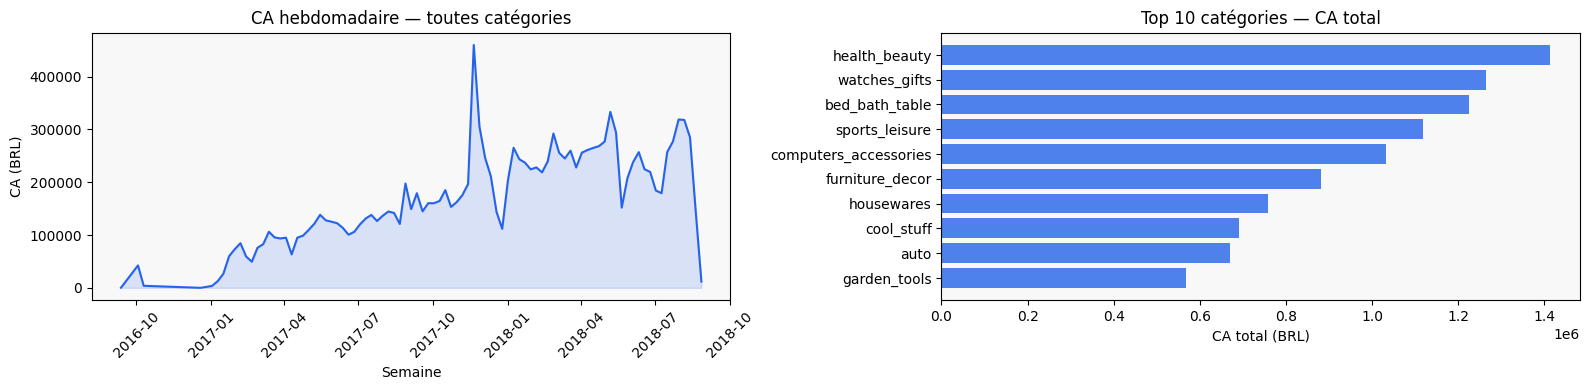

CA moyen / semaine : 167,276 BRL
CA max (semaine)   : 459,801 BRL — semaine du 2017-11-20


In [26]:
# ─────────────────────────────────────────────
# CELLULE 8 — EDA rapide CA global
# ─────────────────────────────────────────────

ca_global = weekly.groupby("week_start")["CA"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Série temporelle globale
axes[0].plot(ca_global.index, ca_global.values, color="#2563EB", lw=1.5)
axes[0].fill_between(ca_global.index, ca_global.values, alpha=0.15, color="#2563EB")
axes[0].set_title("CA hebdomadaire — toutes catégories", fontsize=12)
axes[0].set_xlabel("Semaine") ; axes[0].set_ylabel("CA (BRL)")
axes[0].tick_params(axis='x', rotation=45)

# Top 10 catégories
top10 = weekly.groupby("product_category_name_english")["CA"].sum().nlargest(10)
axes[1].barh(top10.index[::-1], top10.values[::-1], color="#2563EB", alpha=0.8)
axes[1].set_title("Top 10 catégories — CA total", fontsize=12)
axes[1].set_xlabel("CA total (BRL)")

plt.tight_layout()
plt.savefig("eda_ca_global.png", dpi=150)
plt.show()

print(f"CA moyen / semaine : {ca_global.mean():,.0f} BRL")
print(f"CA max (semaine)   : {ca_global.max():,.0f} BRL — semaine du {ca_global.idxmax().date()}")

## 6 — Feature Engineering

Trois familles de features sont créées pour permettre à XGBoost de capturer le passé et la saisonnalité :

| Famille | Features | Rôle |
|---|---|---|
| **Temporelles** | month, quarter, week_of_year, year, is_q4 | Saisonnalité / Black Friday |
| **Lag features** | CA_lag_1, _2, _4, _8 | Valeurs passées → tendance |
| **Rolling mean** | CA_rolling_4w, CA_rolling_8w | Tendance lissée |

> ⚠️ Les lags sont calculés **par catégorie** après un tri chronologique — essentiel pour éviter les fuites de données entre catégories.

In [27]:
# ─────────────────────────────────────────────
# CELLULE 9 — Feature Engineering
# ─────────────────────────────────────────────

df_feat = weekly.copy()

# ── 1. Features temporelles ──
df_feat["month"]        = df_feat["week_start"].dt.month
df_feat["quarter"]      = df_feat["week_start"].dt.quarter
df_feat["week_of_year"] = df_feat["week_start"].dt.isocalendar().week.astype(int)
df_feat["year"]         = df_feat["week_start"].dt.year
df_feat["is_q4"]        = (df_feat["quarter"] == 4).astype(int)

# ── 2. Lag features par catégorie ──
# Tri obligatoire avant calcul des lags
df_feat = df_feat.sort_values(["product_category_name_english", "week_start"])

for lag in [1, 2, 4, 8]:
    df_feat[f"CA_lag_{lag}"] = (
        df_feat.groupby("product_category_name_english")["CA"].shift(lag)
    )

# ── 3. Rolling mean par catégorie ──
df_feat["CA_rolling_4w"] = (
    df_feat.groupby("product_category_name_english")["CA"]
           .transform(lambda x: x.shift(1).rolling(4).mean())
)
df_feat["CA_rolling_8w"] = (
    df_feat.groupby("product_category_name_english")["CA"]
           .transform(lambda x: x.shift(1).rolling(8).mean())
)

# ── 4. Encodage catégorie ──
df_feat["category_encoded"] = pd.factorize(df_feat["product_category_name_english"])[0]

# ── 5. Suppression des NaN générés par les lags ──
df_before = len(df_feat)
df_feat   = df_feat.dropna().reset_index(drop=True)

print(f"Lignes avant dropna : {df_before:,}")
print(f"Lignes après dropna : {len(df_feat):,}")
print(f"\nFeatures finales ({len(df_feat.columns)}) :")
print([c for c in df_feat.columns])

Lignes avant dropna : 4,372
Lignes après dropna : 3,798

Features finales (17) :
['week_start', 'product_category_name_english', 'CA', 'nb_orders', 'avg_price', 'month', 'quarter', 'week_of_year', 'year', 'is_q4', 'CA_lag_1', 'CA_lag_2', 'CA_lag_4', 'CA_lag_8', 'CA_rolling_4w', 'CA_rolling_8w', 'category_encoded']


## 7 — Split Train / Test — Découpe chronologique

> ⚠️ Avec des données temporelles, le split doit être **chronologique** (pas aléatoire).  
> Un split aléatoire provoquerait une **fuite de données** (*data leakage*) : le modèle verrait le futur pendant l'entraînement.

- **Train** : 80% premières semaines
- **Test** : 20% dernières semaines

Date de coupure : 2018-05-21
Train : (3040, 14)  | 2017-02-06 → 2018-05-21
Test  : (758, 14)   | 2018-05-28 → 2018-08-27


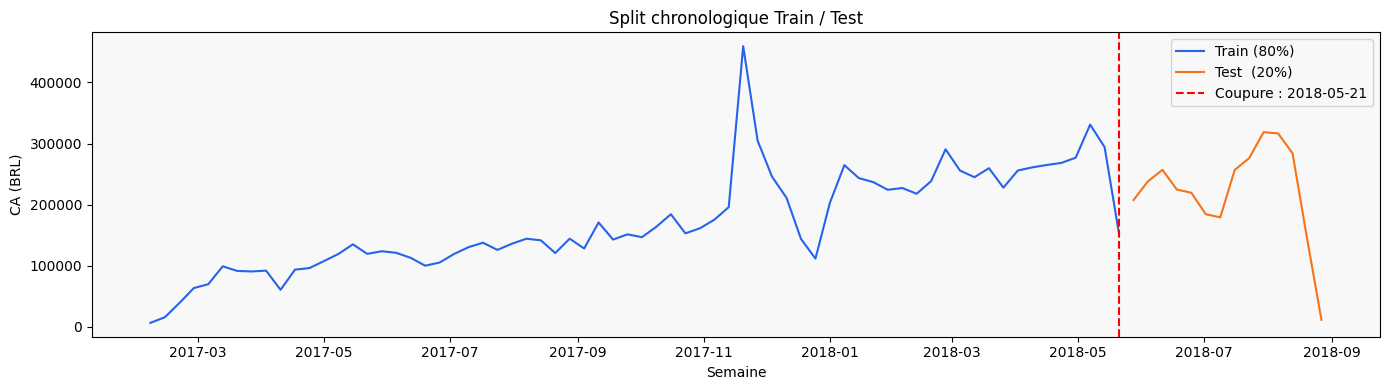

In [28]:
# ─────────────────────────────────────────────
# CELLULE 10 — Split chronologique 80/20
# ─────────────────────────────────────────────

FEATURES = [
    "month", "quarter", "week_of_year", "year", "is_q4",
    "CA_lag_1", "CA_lag_2", "CA_lag_4", "CA_lag_8",
    "CA_rolling_4w", "CA_rolling_8w",
    "nb_orders", "avg_price", "category_encoded"
]
TARGET = "CA"

cutoff = df_feat["week_start"].quantile(0.80)

train = df_feat[df_feat["week_start"] <= cutoff]
test  = df_feat[df_feat["week_start"] >  cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Date de coupure : {cutoff.date()}")
print(f"Train : {X_train.shape}  | {train['week_start'].min().date()} → {train['week_start'].max().date()}")
print(f"Test  : {X_test.shape}   | {test['week_start'].min().date()} → {test['week_start'].max().date()}")

# Visualisation du split
ca_train = train.groupby("week_start")["CA"].sum()
ca_test  = test.groupby("week_start")["CA"].sum()

plt.figure(figsize=(14, 4))
plt.plot(ca_train.index, ca_train.values, color="#2563EB", label="Train (80%)")
plt.plot(ca_test.index,  ca_test.values,  color="#F97316", label="Test  (20%)")
plt.axvline(cutoff, color="red", linestyle="--", lw=1.5, label=f"Coupure : {cutoff.date()}")
plt.title("Split chronologique Train / Test", fontsize=12)
plt.xlabel("Semaine") ; plt.ylabel("CA (BRL)")
plt.legend() ; plt.tight_layout()
plt.savefig("split_train_test.png", dpi=150)
plt.show()

## 8 — Entraînement & Comparaison des 3 modèles

| Modèle | Type | Rôle dans la comparaison |
|---|---|---|
| **Linear Regression** | Baseline linéaire | Référence de comparaison |
| **Random Forest** | Ensemble / Bagging | Robuste, gère les non-linéarités |
| **XGBoost** | Gradient Boosting | Meilleure performance attendue sur données tabulaires |

**Métriques d'évaluation** : RMSE ↓, MAE ↓, R² ↑

In [29]:
# ─────────────────────────────────────────────
# CELLULE 11 — Entraînement des 3 modèles
# ─────────────────────────────────────────────

from sklearn.linear_model import LinearRegression
from sklearn.ensemble     import RandomForestRegressor
from xgboost              import XGBRegressor
from sklearn.metrics      import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest"     : RandomForestRegressor(
                              n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost"           : XGBRegressor(
                              n_estimators=300, learning_rate=0.05,
                              max_depth=6,      subsample=0.8,
                              colsample_bytree=0.8,
                              random_state=42,  verbosity=0)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    results[name] = {"RMSE": rmse, "MAE": mae, "R²": r2,
                     "model": model, "preds": preds}
    print(f"[{name:<20}]  RMSE={rmse:>10,.0f}  |  MAE={mae:>9,.0f}  |  R²={r2:.4f}")

# Tableau comparatif
results_df = pd.DataFrame(
    {k: {m: v[m] for m in ["RMSE", "MAE", "R²"]} for k, v in results.items()}
).T.sort_values("R²", ascending=False)

print("\n── Classement des modèles (trié par R²) ──")
print(results_df.round(4))

[Linear Regression   ]  RMSE=     1,580  |  MAE=      906  |  R²=0.9394
[Random Forest       ]  RMSE=       864  |  MAE=      434  |  R²=0.9819
[XGBoost             ]  RMSE=       926  |  MAE=      426  |  R²=0.9792

── Classement des modèles (trié par R²) ──
                        RMSE       MAE      R²
Random Forest       864.4627  434.4019  0.9819
XGBoost             925.9168  425.7748  0.9792
Linear Regression  1580.3512  905.6438  0.9394


### Visualisation comparative des métriques

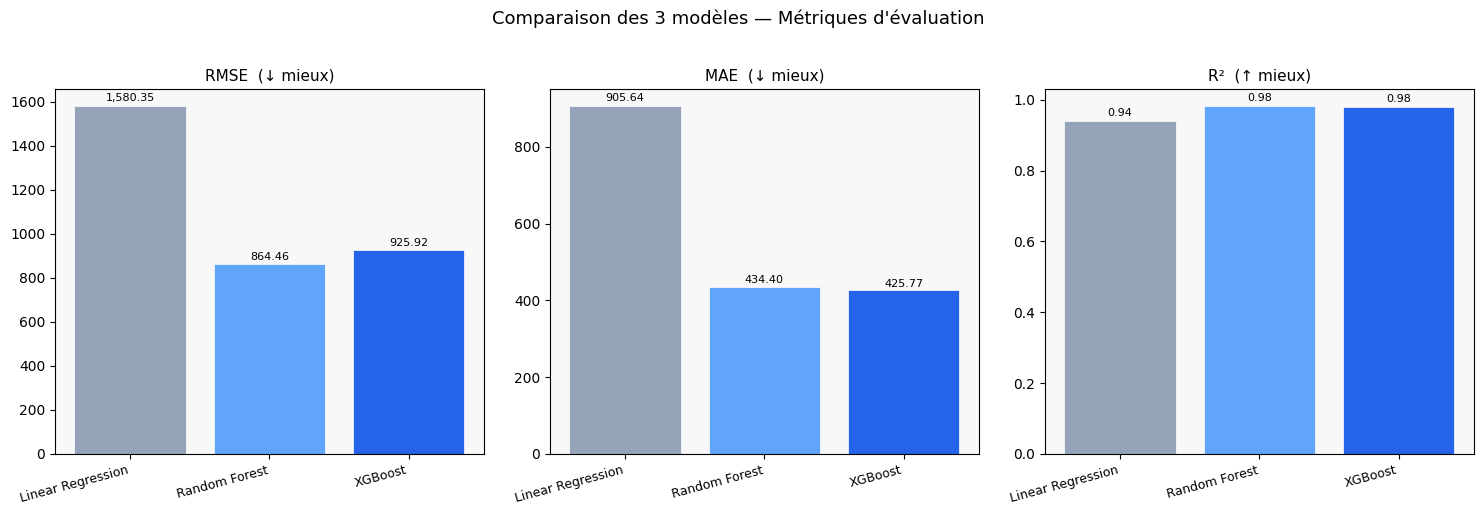

In [30]:
# ─────────────────────────────────────────────
# CELLULE 12 — Graphique comparatif métriques
# ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors    = ["#94A3B8", "#60A5FA", "#2563EB"]
names     = list(results.keys())

for ax, metric, better in zip(axes,
                               ["RMSE",    "MAE",    "R²"],
                               ["lower",   "lower",  "higher"]):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_title(f"{metric}  ({'↓ mieux' if better == 'lower' else '↑ mieux'})",
                 fontsize=11)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=15, ha="right", fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.01,
                f"{val:,.2f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Comparaison des 3 modèles — Métriques d'évaluation",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("comparaison_modeles.png", dpi=150)
plt.show()

## 9 — Interprétabilité — SHAP Values

Conformément aux exigences du cahier des charges DDDM, l'interprétabilité est obligatoire.  
Les **SHAP values** expliquent les prédictions à deux niveaux :

- **Global** : quelles features influencent le plus le modèle en moyenne
- **Local** : dans quelle direction chaque feature pousse chaque prédiction individuelle

── SHAP — Importance globale des features (Random Forest) ──


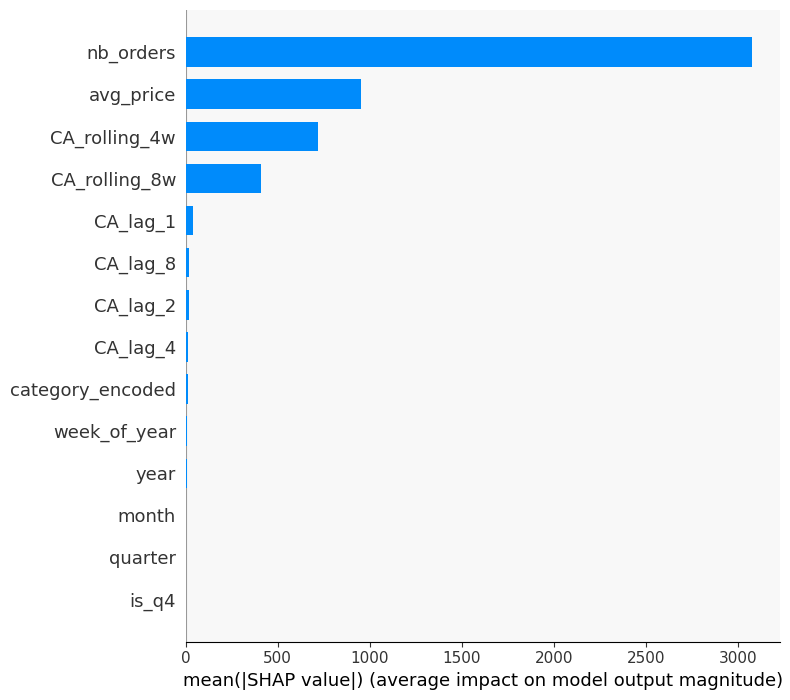

── SHAP — Direction des effets (Random Forest) ──


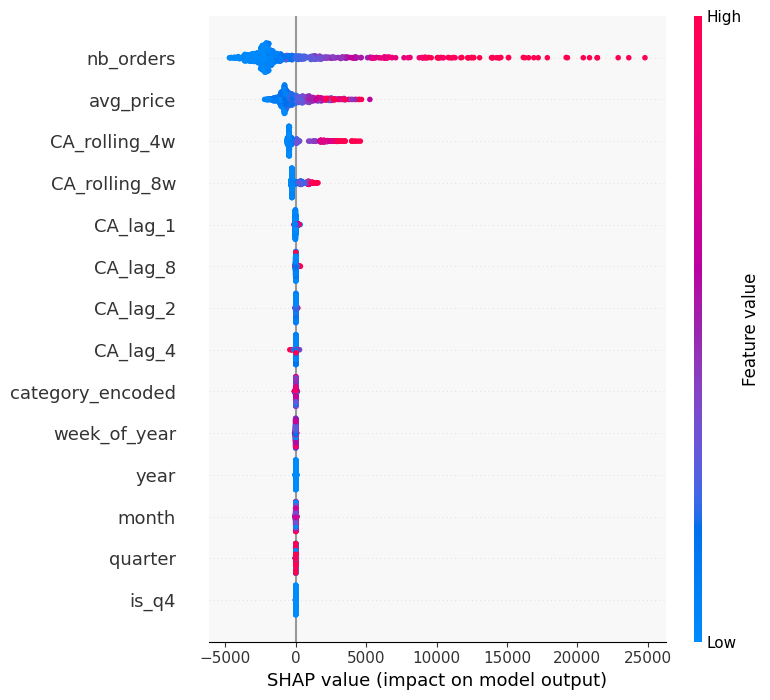

In [31]:
# ─────────────────────────────────────────────
# CELLULE 13 — SHAP Values
# ─────────────────────────────────────────────
# !pip install shap  # décommenter si nécessaire
import shap

# ── CHANGEMENT : XGBoost → Random Forest ──
best_model  = results["Random Forest"]["model"]  
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Sécurité Random Forest (si shap retourne une liste)
shap_values = shap_values[1] if isinstance(shap_values, list) else shap_values

# ── Plot 1 : importance globale ──
print("── SHAP — Importance globale des features (Random Forest) ──")
shap.summary_plot(shap_values, X_test, feature_names=FEATURES,
                  plot_type="bar", show=True)

# ── Plot 2 : direction des effets (beeswarm) ──
print("── SHAP — Direction des effets (Random Forest) ──")
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=True)

## 10 — Visualisation des prédictions

### 10.1 — CA global : Réel vs Prédit

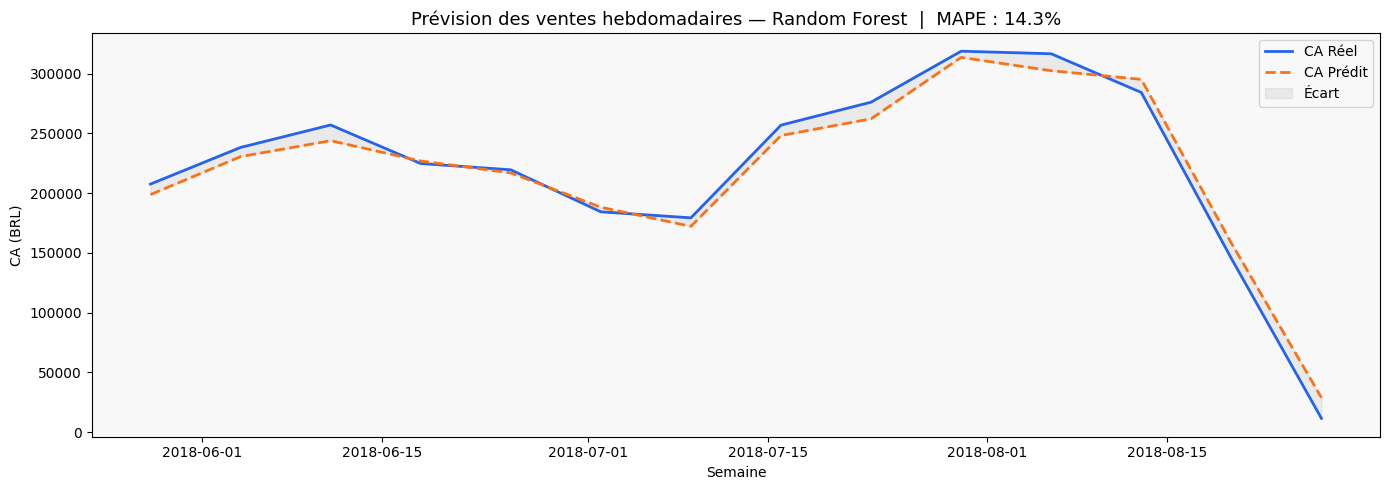

MAPE : 14.27%


In [33]:
# ─────────────────────────────────────────────
# CELLULE 14 — Réel vs Prédit (CA global)
# ─────────────────────────────────────────────

test_agg              = test.copy()
test_agg["predicted"] = results["Random Forest"]["preds"] 

weekly_real = test_agg.groupby("week_start")["CA"].sum()
weekly_pred = test_agg.groupby("week_start")["predicted"].sum()

mape = (abs(weekly_real - weekly_pred) / weekly_real).mean() * 100

plt.figure(figsize=(14, 5))
plt.plot(weekly_real.index, weekly_real.values,
         label="CA Réel",   color="#2563EB", lw=2)
plt.plot(weekly_pred.index, weekly_pred.values,
         label="CA Prédit", color="#F97316", lw=2, linestyle="--")
plt.fill_between(weekly_real.index,
                 weekly_real.values, weekly_pred.values,
                 alpha=0.12, color="gray", label="Écart")
plt.title(f"Prévision des ventes hebdomadaires — Random Forest  |  MAPE : {mape:.1f}%",  
          fontsize=13)
plt.xlabel("Semaine") ; plt.ylabel("CA (BRL)")
plt.legend() ; plt.tight_layout()
plt.savefig("prevision_ventes_random_forest.png", dpi=150)  
plt.show()

print(f"MAPE : {mape:.2f}%")

### 10.2 — Prévision par catégorie — Top 5 CA

Prévision hebdomadaire — semaine suivante par catégorie
Top 5 catégories sélectionnées sur CA total (train + test)
Période de test : 2018-05-28 → 2018-08-27

Top 5 : ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories']



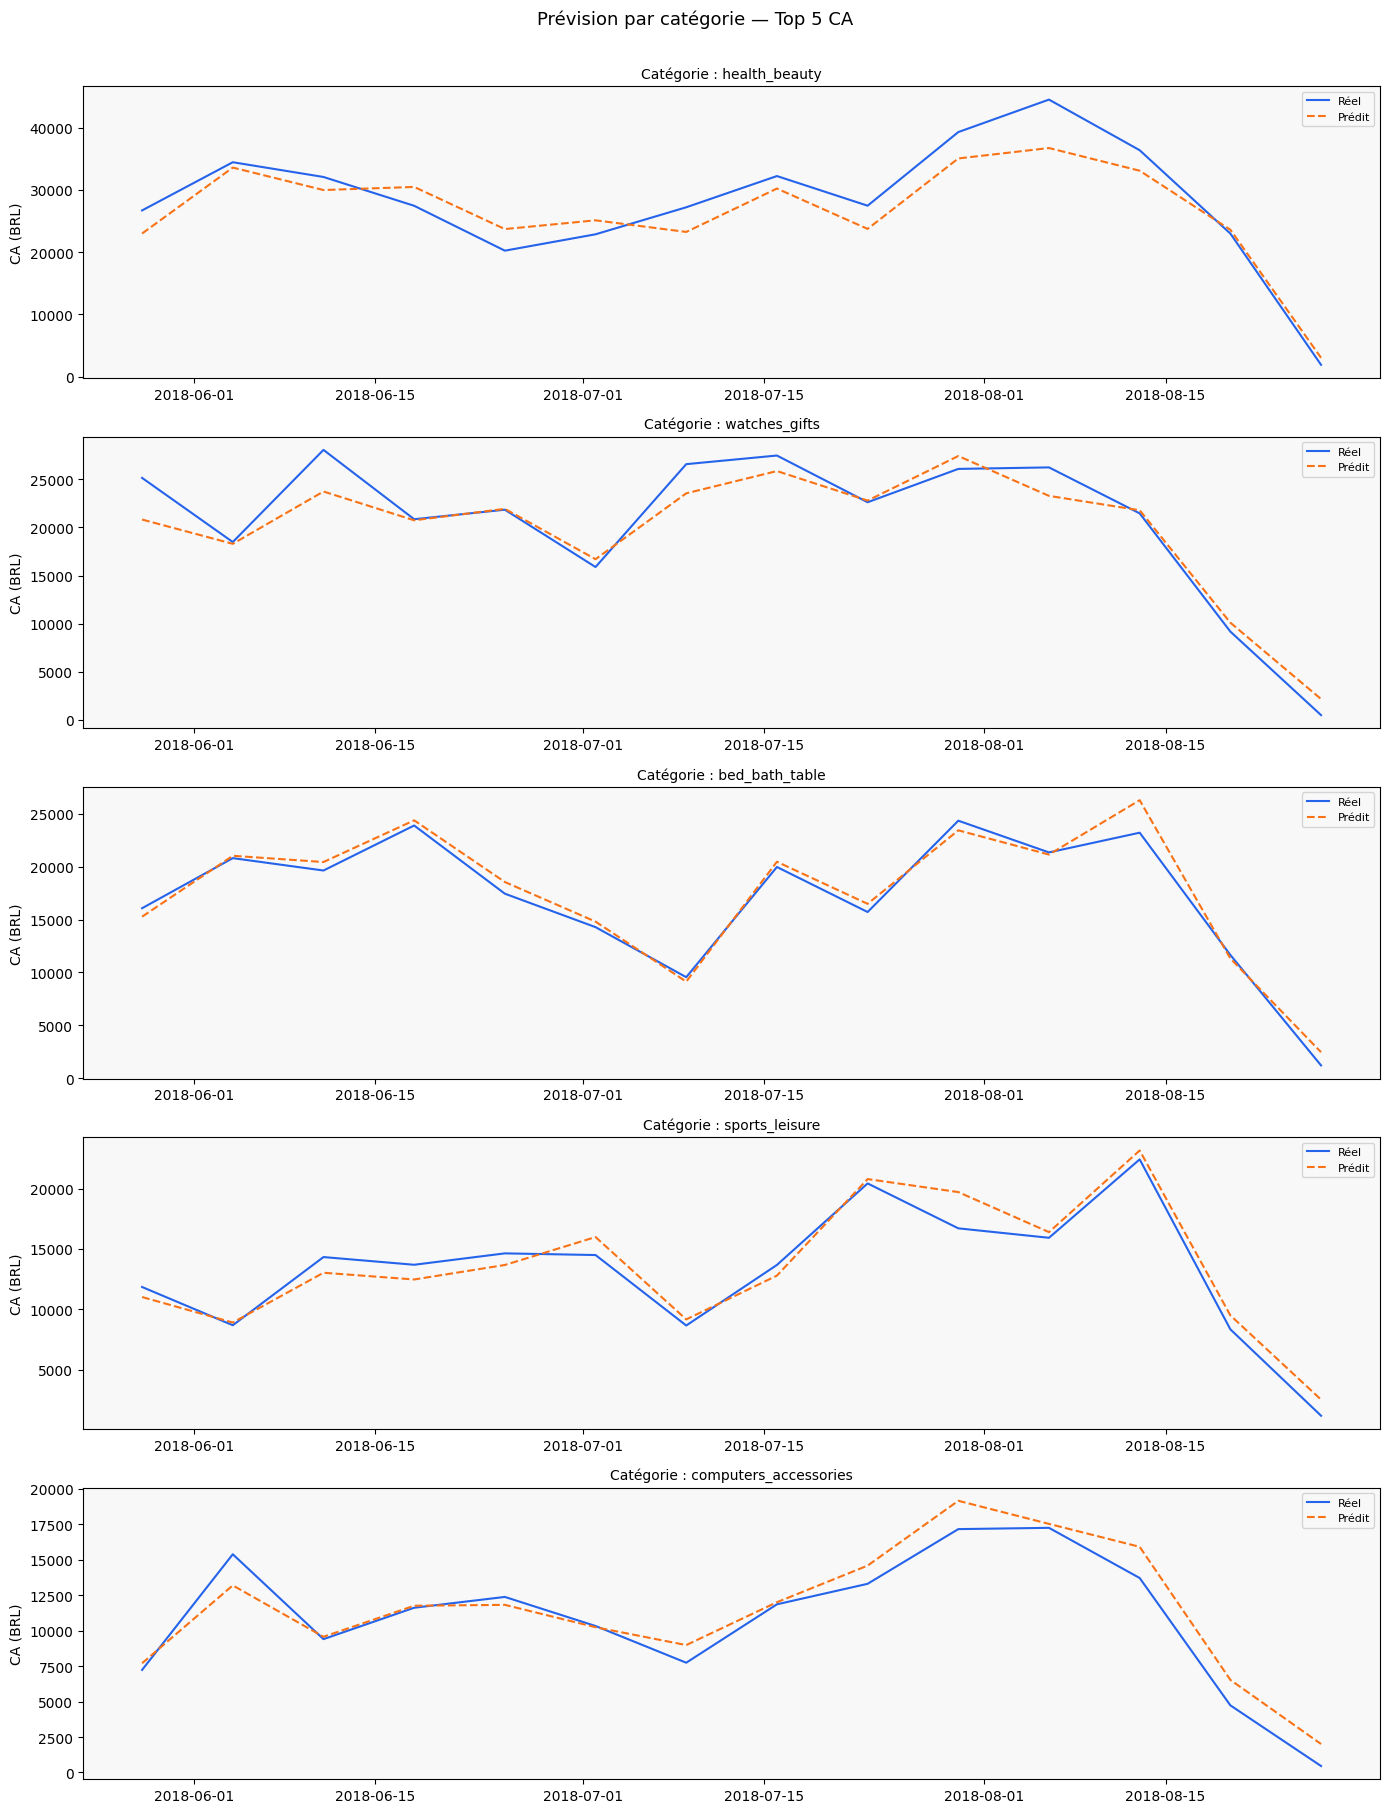

In [37]:
# ─────────────────────────────────────────────
# CELLULE 15 — Prévision Top 5 catégories
# Granularité : hebdomadaire (prédiction semaine suivante)
# Période visualisée : jeu de test (mai → août 2018)
# ─────────────────────────────────────────────

print("Prévision hebdomadaire — semaine suivante par catégorie")
print(f"Top 5 catégories sélectionnées sur CA total (train + test)")
print(f"Période de test : {test_agg['week_start'].min().date()} → {test_agg['week_start'].max().date()}")
print()

top5_cats = (
    df_model.groupby("product_category_name_english")["revenue"]
    .sum().nlargest(5).index.tolist()
)
print(f"Top 5 : {top5_cats}")
print()
fig, axes = plt.subplots(5, 1, figsize=(14, 18))

for ax, cat in zip(axes, top5_cats):
    cat_test = test_agg[test_agg["product_category_name_english"] == cat]
    if cat_test.empty:
        ax.set_title(f"{cat} — pas de données en test") ; continue
    real = cat_test.groupby("week_start")["CA"].sum()
    pred = cat_test.groupby("week_start")["predicted"].sum()
    ax.plot(real.index, real.values, label="Réel",   color="#2563EB", lw=1.5)
    ax.plot(pred.index, pred.values, label="Prédit", color="#F97316",
            lw=1.5, linestyle="--")
    ax.set_title(f"Catégorie : {cat}", fontsize=10)
    ax.legend(fontsize=8) ; ax.set_ylabel("CA (BRL)")

plt.suptitle("Prévision par catégorie — Top 5 CA", fontsize=13, y=1.005)
plt.tight_layout()
plt.savefig("prevision_par_categorie.png", dpi=150)
plt.show()

## 11 — Synthèse des résultats

In [36]:
# ─────────────────────────────────────────────
# CELLULE 16 — Synthèse finale
# ─────────────────────────────────────────────

print("=" * 60)
print("   SYNTHÈSE — MODÈLE 1 : PRÉVISION DES VENTES")
print("=" * 60)

print("\n── Comparaison des 3 modèles ──")
print(results_df.round(4))

best_name = results_df["R²"].idxmax()
best      = results[best_name]

print(f"\n── Meilleur modèle retenu : {best_name} ──")
print(f"   RMSE : {best['RMSE']:,.0f} BRL")
print(f"   MAE  : {best['MAE']:,.0f} BRL")
print(f"   R²   : {best['R²']:.4f}")
print(f"   MAPE : {mape:.2f}%")

print("\n── Top features (SHAP — importance moyenne) ──")
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0), index=FEATURES
).sort_values(ascending=False)
print(shap_importance.round(2).head(10).to_string())

print("\n── Conclusion ──")
print(f"{best_name} est le modèle retenu pour la prévision des ventes.")
print("Les features les plus déterminantes sont nb_orders (volume)")
print("et avg_price (prix moyen), suivis des rolling means.")
print("Les lag features ont un impact secondaire.")

   SYNTHÈSE — MODÈLE 1 : PRÉVISION DES VENTES

── Comparaison des 3 modèles ──
                        RMSE       MAE      R²
Random Forest       864.4627  434.4019  0.9819
XGBoost             925.9168  425.7748  0.9792
Linear Regression  1580.3512  905.6438  0.9394

── Meilleur modèle retenu : Random Forest ──
   RMSE : 864 BRL
   MAE  : 434 BRL
   R²   : 0.9819
   MAPE : 14.27%

── Top features (SHAP — importance moyenne) ──
nb_orders           3075.03
avg_price            952.21
CA_rolling_4w        716.96
CA_rolling_8w        407.19
CA_lag_1              41.31
CA_lag_8              17.93
CA_lag_2              15.53
CA_lag_4              13.94
category_encoded      11.73
week_of_year           6.58

── Conclusion ──
Random Forest est le modèle retenu pour la prévision des ventes.
Les features les plus déterminantes sont nb_orders (volume)
et avg_price (prix moyen), suivis des rolling means.
Les lag features ont un impact secondaire.
